In [86]:
# Imports

import torch
import copy
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib
import os

In [87]:
# Check device (cpu or gpu)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [88]:

# Load engineered data and preprocessor
merged_df = pd.read_parquet('../data/processed/merged_engineered.parquet')
preprocessor_new = joblib.load('../models/preprocessor_engineered.pkl')

# Features
num_features_new = ['budget_tmdb', 'runtime_tmdb', 'popularity_tmdb', 'vote_count_tmdb', 'user_rating_count', 'num_genres', 'num_cast', 'num_crew', 
                    'release_year', 'cast_popularity', 'keyword_count', 'pos_keyword_ratio', 'director_score', 'overview_length']
cat_features = ['primary_genre', 'original_language_tmdb', 'release_season', 'adult_tmdb']

X_new = merged_df[num_features_new + cat_features]
y_revenue_new = merged_df['log_revenue']
y_rating_new = merged_df['avg_user_rating']

# Splits 
X_train_new, X_test_new, y_rev_train_new, y_rev_test_new = train_test_split(X_new, y_revenue_new, test_size=0.2, random_state=42)
_, _, y_rat_train_new, y_rat_test_new = train_test_split(X_new, y_rating_new, test_size=0.2, random_state=42)

# Preprocess
X_train_proc_new = preprocessor_new.transform(X_train_new)
X_test_proc_new = preprocessor_new.transform(X_test_new)
feature_names_new = preprocessor_new.get_feature_names_out()

# Split train into train/val (80/20)
X_train_proc, X_val_proc, y_rev_train_new, y_rev_val_new = train_test_split(X_train_proc_new, y_rev_train_new, test_size=0.2, random_state=42)
_, _, y_rat_train_new, y_rat_val_new = train_test_split(X_train_proc_new, y_rat_train_new, test_size=0.2, random_state=42)

# To Tensors
X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val_proc, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_proc_new, dtype=torch.float32).to(device)
y_rev_train_tensor = torch.tensor(y_rev_train_new.values, dtype=torch.float32).view(-1, 1).to(device)
y_rev_val_tensor = torch.tensor(y_rev_val_new.values, dtype=torch.float32).view(-1, 1).to(device)
y_rat_train_tensor = torch.tensor(y_rat_train_new.values, dtype=torch.float32).view(-1, 1).to(device)
y_rat_val_tensor = torch.tensor(y_rat_val_new.values, dtype=torch.float32).view(-1, 1).to(device)

print(f"Val Shapes: X_val {X_val_tensor.shape}, Revenue Y_val {y_rev_val_tensor.shape}")
print(f"Data Shapes: Train X {X_train_tensor.shape}, Revenue Y {y_rev_train_tensor.shape}")

Val Shapes: X_val torch.Size([952, 70]), Revenue Y_val torch.Size([952, 1])
Data Shapes: Train X torch.Size([3808, 70]), Revenue Y torch.Size([3808, 1])


In [89]:
# Define Simple Feedforward NN Model

class MovieSuccessNN(nn.Module):
    def __init__(self, input_size: int, hidden_sizes: list[int] = [128, 64], dropout: float = 0.2):
        super(MovieSuccessNN, self).__init__()
        layers = []
        prev_size = input_size
        for hidden in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = hidden
        layers.append(nn.Linear(prev_size, 1))  # Regression output
        self.network = nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

#  Check input size
input_size = X_train_proc_new.shape[1]
print(f"Input size: {input_size}")

# Init models
nn_rev = MovieSuccessNN(input_size).to(device)
nn_rat = MovieSuccessNN(input_size).to(device)

print(nn_rev)  # Model summary

Input size: 70
MovieSuccessNN(
  (network): Sequential(
    (0): Linear(in_features=70, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


Starting training...
Epoch 50/1000 | Train Loss: 5.3273 | Val Loss: 2.5340
Epoch 100/1000 | Train Loss: 4.7976 | Val Loss: 2.0229
Epoch 150/1000 | Train Loss: 4.6738 | Val Loss: 1.9536
Epoch 200/1000 | Train Loss: 4.4314 | Val Loss: 1.8517
Epoch 250/1000 | Train Loss: 4.3021 | Val Loss: 1.8061
Epoch 300/1000 | Train Loss: 4.3130 | Val Loss: 1.7402
Epoch 350/1000 | Train Loss: 4.3245 | Val Loss: 1.7010
Epoch 400/1000 | Train Loss: 4.1189 | Val Loss: 1.6424
Epoch 450/1000 | Train Loss: 3.9825 | Val Loss: 1.5939
Epoch 500/1000 | Train Loss: 4.0472 | Val Loss: 1.5705
Epoch 550/1000 | Train Loss: 3.8139 | Val Loss: 1.5352
Epoch 600/1000 | Train Loss: 3.8246 | Val Loss: 1.5116
Epoch 650/1000 | Train Loss: 3.7935 | Val Loss: 1.5034
Epoch 700/1000 | Train Loss: 3.6720 | Val Loss: 1.5007
Epoch 750/1000 | Train Loss: 3.6229 | Val Loss: 1.4922
Epoch 800/1000 | Train Loss: 3.4535 | Val Loss: 1.4810
Epoch 850/1000 | Train Loss: 3.5407 | Val Loss: 1.4876
Epoch 900/1000 | Train Loss: 3.4288 | Val Los

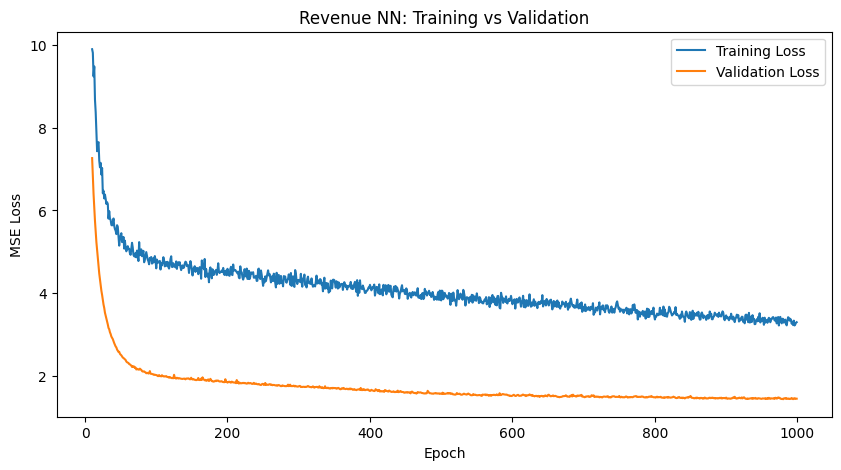

In [90]:
# Revenue NN

# Create the Train Loader (Shuffle = True)
train_loader_rev = DataLoader(TensorDataset(X_train_tensor, y_rev_train_tensor), batch_size=64, shuffle=True)

# Create the Validation Loader (Shuffle = False)
val_loader_rev = DataLoader(TensorDataset(X_val_tensor, y_rev_val_tensor), batch_size=64, shuffle=False)

optimizer_rev = optim.Adam(nn_rev.parameters(), lr=0.0001) 
criterion = nn.MSELoss()
num_epochs = 1000

train_losses_rev = []
val_losses_rev = []

# Training loop
print("Starting training...")
for epoch in range(num_epochs):
    # Train
    nn_rev.train()  # Turn Dropout on
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader_rev:
        optimizer_rev.zero_grad()
        outputs = nn_rev(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_rev.step()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader_rev)
    train_losses_rev.append(avg_train_loss)
    
    # Validate
    nn_rev.eval()   # Turn Dropout off for accurate metrics
    epoch_val_loss = 0
    with torch.no_grad(): # Don't calculate gradients
        for X_val, y_val in val_loader_rev:
            val_outputs = nn_rev(X_val)
            v_loss = criterion(val_outputs, y_val)
            epoch_val_loss += v_loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader_rev)
    val_losses_rev.append(avg_val_loss)

    # Logging
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")


skip = 10  # Skip the first 10 epochs to avoid the initial spike distorting the graph
plt.figure(figsize=(10, 5))
plt.plot(range(skip, len(train_losses_rev)), train_losses_rev[skip:], label='Training Loss')
plt.plot(range(skip, len(val_losses_rev)), val_losses_rev[skip:], label='Validation Loss')
plt.title('Revenue NN: Training vs Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.savefig('../reports/figures/revenue_nn_loss_val.png')
plt.show()

Revenue Neural Network
RMSE: 1.2795
MAE: 0.8780
R-squared: 0.5823


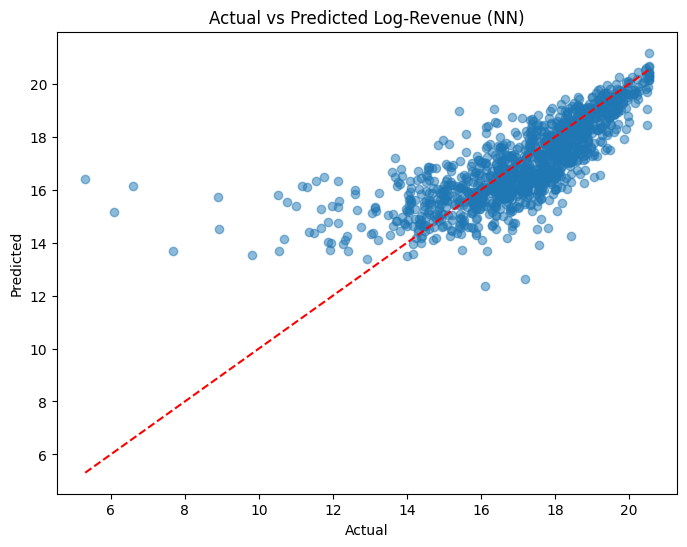

In [91]:
# Evaluate Revenue NN
nn_rev.eval()
with torch.no_grad():
    y_pred_rev_nn = nn_rev(X_test_tensor).cpu().numpy()

rmse_rev_nn = np.sqrt(mean_squared_error(y_rev_test_new, y_pred_rev_nn))
mae_rev_nn = mean_absolute_error(y_rev_test_new, y_pred_rev_nn)
r2_rev_nn = r2_score(y_rev_test_new, y_pred_rev_nn)

print("Revenue Neural Network")
print(f"RMSE: {rmse_rev_nn:.4f}")
print(f"MAE: {mae_rev_nn:.4f}")
print(f"R-squared: {r2_rev_nn:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_rev_test_new, y_pred_rev_nn, alpha=0.5)
plt.plot([y_rev_test_new.min(), y_rev_test_new.max()], [y_rev_test_new.min(), y_rev_test_new.max()], 'r--')
plt.title('Actual vs Predicted Log-Revenue (NN)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig('../reports/figures/revenue_nn_pred.png')
plt.show()

Starting ratings training...
Ratings Epoch 50/1000 | Train Loss: 0.2458 | Val Loss: 0.1554
Ratings Epoch 100/1000 | Train Loss: 0.2059 | Val Loss: 0.1401
Ratings Epoch 150/1000 | Train Loss: 0.1911 | Val Loss: 0.1280
Ratings Epoch 200/1000 | Train Loss: 0.1806 | Val Loss: 0.1247
Ratings Epoch 250/1000 | Train Loss: 0.1694 | Val Loss: 0.1245
Ratings Epoch 300/1000 | Train Loss: 0.1550 | Val Loss: 0.1188
Ratings Epoch 350/1000 | Train Loss: 0.1475 | Val Loss: 0.1184
Ratings Epoch 400/1000 | Train Loss: 0.1382 | Val Loss: 0.1182
Ratings Epoch 450/1000 | Train Loss: 0.1321 | Val Loss: 0.1178
Ratings Epoch 500/1000 | Train Loss: 0.1313 | Val Loss: 0.1189
Ratings Epoch 550/1000 | Train Loss: 0.1262 | Val Loss: 0.1190
Ratings Epoch 600/1000 | Train Loss: 0.1204 | Val Loss: 0.1204
Ratings Epoch 650/1000 | Train Loss: 0.1137 | Val Loss: 0.1182
Ratings Epoch 700/1000 | Train Loss: 0.1101 | Val Loss: 0.1180
Ratings Epoch 750/1000 | Train Loss: 0.1104 | Val Loss: 0.1181
Ratings Epoch 800/1000 | Tr

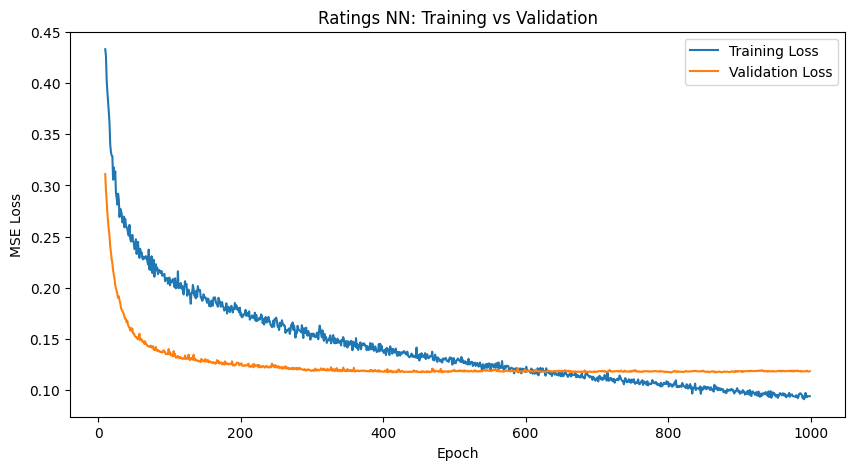

In [92]:
# Ratings NN

# Create the Train Loader (Shuffle = True)
train_loader_rat = DataLoader(TensorDataset(X_train_tensor, y_rat_train_tensor), batch_size=64, shuffle=True)

# Create the Validation Loader (Shuffle = False)
val_loader_rat = DataLoader(TensorDataset(X_val_tensor, y_rat_val_tensor), batch_size=64, shuffle=False)

optimizer_rat = optim.Adam(nn_rat.parameters(), lr=0.0001) 
criterion = nn.MSELoss()
num_epochs = 1000

train_losses_rat = []
val_losses_rat = []

best_val_loss = float('inf')
best_model_wts = copy.deepcopy(nn_rat.state_dict())

# Training loop
print("Starting ratings training...")
for epoch in range(num_epochs):
    # Train
    nn_rat.train()  # Turn Dropout on
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader_rat:
        optimizer_rat.zero_grad()
        outputs = nn_rat(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_rat.step()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader_rat)
    train_losses_rat.append(avg_train_loss)
    
    # Validate
    nn_rat.eval()   # Turn Dropout off for accurate metrics
    epoch_val_loss = 0
    with torch.no_grad(): # Don't calculate gradients
        for X_val, y_val in val_loader_rat:
            val_outputs = nn_rat(X_val)
            v_loss = criterion(val_outputs, y_val)
            epoch_val_loss += v_loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader_rat)
    val_losses_rat.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(nn_rat.state_dict())

    # Logging
    if (epoch + 1) % 50 == 0:
        print(f"Ratings Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

nn_rat.load_state_dict(best_model_wts)

skip = 10  # Skip the first 10 epochs to avoid the initial spike distorting the graph
plt.figure(figsize=(10, 5))
plt.plot(range(skip, len(train_losses_rat)), train_losses_rat[skip:], label='Training Loss')
plt.plot(range(skip, len(val_losses_rat)), val_losses_rat[skip:], label='Validation Loss')
plt.title('Ratings NN: Training vs Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.savefig('../reports/figures/ratings_nn_loss_val.png')
plt.show()

Ratings Neural Network
RMSE: 0.3351
MAE: 0.2558
R-squared: 0.5568


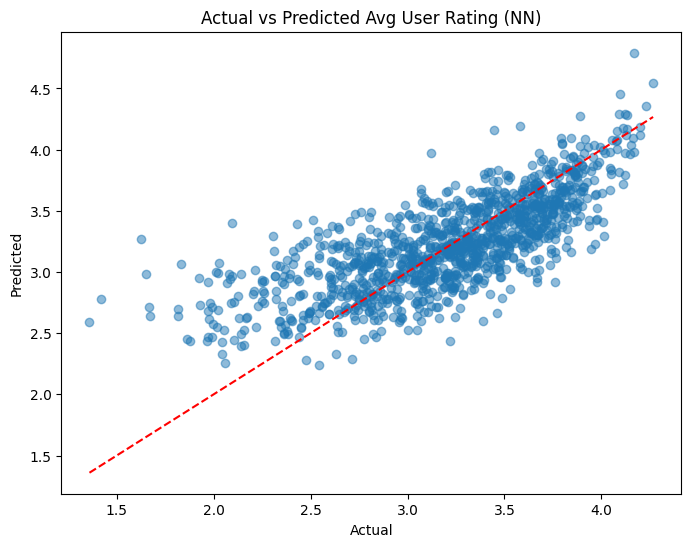

In [94]:
# Evaluate Ratings NN
nn_rat.eval()
with torch.no_grad():
    y_pred_rat_nn = nn_rat(X_test_tensor).cpu().numpy()

rmse_rat_nn = np.sqrt(mean_squared_error(y_rat_test_new, y_pred_rat_nn))
mae_rat_nn = mean_absolute_error(y_rat_test_new, y_pred_rat_nn)
r2_rat_nn = r2_score(y_rat_test_new, y_pred_rat_nn)

print("Ratings Neural Network")
print(f"RMSE: {rmse_rat_nn:.4f}")
print(f"MAE: {mae_rat_nn:.4f}")
print(f"R-squared: {r2_rat_nn:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_rat_test_new, y_pred_rat_nn, alpha=0.5)
plt.plot([y_rat_test_new.min(), y_rat_test_new.max()], [y_rat_test_new.min(), y_rat_test_new.max()], 'r--')
plt.title('Actual vs Predicted Avg User Rating (NN)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig('../reports/figures/ratings_nn_pred.png')
plt.show()

In [95]:
# Save models for comparison next
torch.save(nn_rev.state_dict(), '../models/nn_revenue.pth')
torch.save(nn_rat.state_dict(), '../models/nn_rating.pth')